In [ ]:
!pip install scipy numpy matplotlib pandas scikit-learn --quiet

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import betaln, digamma
import pandas as pd
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'lines.linewidth': 2.3,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [ ]:
data  = load_breast_cancer() # We can use other datasets as well.
df    = pd.DataFrame(data.data, columns=data.feature_names)
df['label'] = data.target   # 1 = benign, 0 = malignant

n = len(df)
k = int(df['label'].sum())
MLE = k / n

print("=" * 55)
print("  Dataset: UCI Breast Cancer Wisconsin")
print("=" * 55)
print(f"  Total samples      n = {n}")
print(f"  Benign    (Y=1)    k = {k}   ({100*k/n:.1f}%)")
print(f"  Malignant (Y=0)  n-k = {n-k}   ({100*(n-k)/n:.1f}%)")
print(f"  MLE  θ̂ = k/n       = {MLE:.4f}")
print("=" * 55)
print()
print("Model:  X ~ Binomial(n, θ)")
print("Goal:   Estimate θ = P(benign) under different priors")
print("Conjugate family: Beta prior  →  Beta posterior")
print()
print("  Prior:     θ ~ Beta(α, β)")
print("  Posterior: θ | data ~ Beta(α + k,  β + n - k)")

  Dataset: UCI Breast Cancer Wisconsin
  Total samples      n = 569
  Benign    (Y=1)    k = 357   (62.7%)
  Malignant (Y=0)  n-k = 212   (37.3%)
  MLE  θ̂ = k/n       = 0.6274

Model:  X ~ Binomial(n, θ)
Goal:   Estimate θ = P(benign) under different priors
Conjugate family: Beta prior  →  Beta posterior

  Prior:     θ ~ Beta(α, β)
  Posterior: θ | data ~ Beta(α + k,  β + n - k)


In [ ]:
theta = np.linspace(1e-4, 1 - 1e-4, 2000)

priors = {
    "Haldane\nBeta(0.001, 0.001)": {
        "a": 0.001, "b": 0.001, "color": "#555555",
        "note": "Improper limit. Places mass at 0 and 1 only.\nHighly data-driven. Undefined mean/MAP without data."
    },
    "Jeffreys\nBeta(0.5, 0.5)": {
        "a": 0.5, "b": 0.5, "color": "#1D9E75",
        "note": "Invariant under reparametrisation.\nTheoretically principled non-informative prior."
    },
    "Uniform\nBeta(1, 1)": {
        "a": 1.0, "b": 1.0, "color": "#7F77DD",
        "note": "Equal probability to all θ.\nMAP = MLE under this prior."
    },
    "Weakly Informative\nBeta(2, 2)": {
        "a": 2.0, "b": 2.0, "color": "#E8A838",
        "note": "Symmetric. Mild belief that θ ≈ 0.5.\nLow influence on posterior."
    },
    "Correct Informative\nBeta(15, 8)": {
        "a": 15.0, "b": 8.0, "color": "#378ADD",
        "note": "Prior mean ≈ 0.65 — close to true value.\nRepresents good domain knowledge."
    },
    "Overconfident\nBeta(50, 50)": {
        "a": 50.0, "b": 50.0, "color": "#E87D3E",
        "note": "Strongly believes θ = 0.5.\nVery tight — resists data. Shows prior-data tension."
    },
    "Misspecified\nBeta(2, 15)": {
        "a": 2.0, "b": 15.0, "color": "#D4537E",
        "note": "Wrong prior: believes malignant dominates (θ ≈ 0.12).\nShows how bad priors are overcome by data."
    },
}

# Compute posterior parameters and all derived quantities
for name, p in priors.items():
    a_post = p["a"] + k
    b_post = p["b"] + (n - k)
    post_mean   = a_post / (a_post + b_post)
    post_median = stats.beta.ppf(0.5, a_post, b_post)
    MAP = (a_post - 1) / (a_post + b_post - 2) if (a_post > 1 and b_post > 1) else None

    # KL divergence: KL(posterior || prior) tells us how much data moved belief
    def kl_beta(a1, b1, a2, b2):
        return (betaln(a2, b2) - betaln(a1, b1)
                + (a1 - a2) * digamma(a1)
                + (b1 - b2) * digamma(b1)
                + (a2 - a1 + b2 - b1) * digamma(a1 + b1))

    kl = kl_beta(a_post, b_post, p["a"], p["b"])

    # Posterior predictive P(X_new = 1 | data) = posterior mean
    post_pred = post_mean

    p.update({
        "a_post": a_post, "b_post": b_post,
        "post_mean":   post_mean,
        "post_median": post_median,
        "MAP":         MAP,
        "KL":          kl,
        "post_pred":   post_pred,
        "prior_pdf":   stats.beta.pdf(theta, p["a"],  p["b"]),
        "post_pdf":    stats.beta.pdf(theta, a_post, b_post),
        "prior_mean":  p["a"] / (p["a"] + p["b"]),
    })

print(f"{'Prior':<35} {'α_post':>8} {'β_post':>8} {'Post.Mean':>10} {'MAP':>8} {'KL↑':>8}")
print("-" * 80)
for name, p in priors.items():
    nm    = name.replace('\n', ' ')
    map_s = f"{p['MAP']:.4f}" if p['MAP'] else "undef."
    print(f"{nm:<35} {p['a_post']:>8.1f} {p['b_post']:>8.1f} "
          f"{p['post_mean']:>10.4f} {map_s:>8} {p['KL']:>8.3f}")
print(f"\nMLE = {MLE:.4f}  (reference — no prior)")

Prior                                 α_post   β_post  Post.Mean      MAP      KL↑
--------------------------------------------------------------------------------
Haldane Beta(0.001, 0.001)             357.0    212.0     0.6274   0.6279    8.628
Jeffreys Beta(0.5, 0.5)                357.5    212.5     0.6272   0.6276    2.899
Uniform Beta(1, 1)                     358.0    213.0     0.6270   0.6274    2.482
Weakly Informative Beta(2, 2)          359.0    214.0     0.6265   0.6270    2.146
Correct Informative Beta(15, 8)        372.0    220.0     0.6284   0.6288    1.197
Overconfident Beta(50, 50)             407.0    262.0     0.6084   0.6087    2.916
Misspecified Beta(2, 15)               359.0    227.0     0.6126   0.6130   10.794

MLE = 0.6274  (reference — no prior)


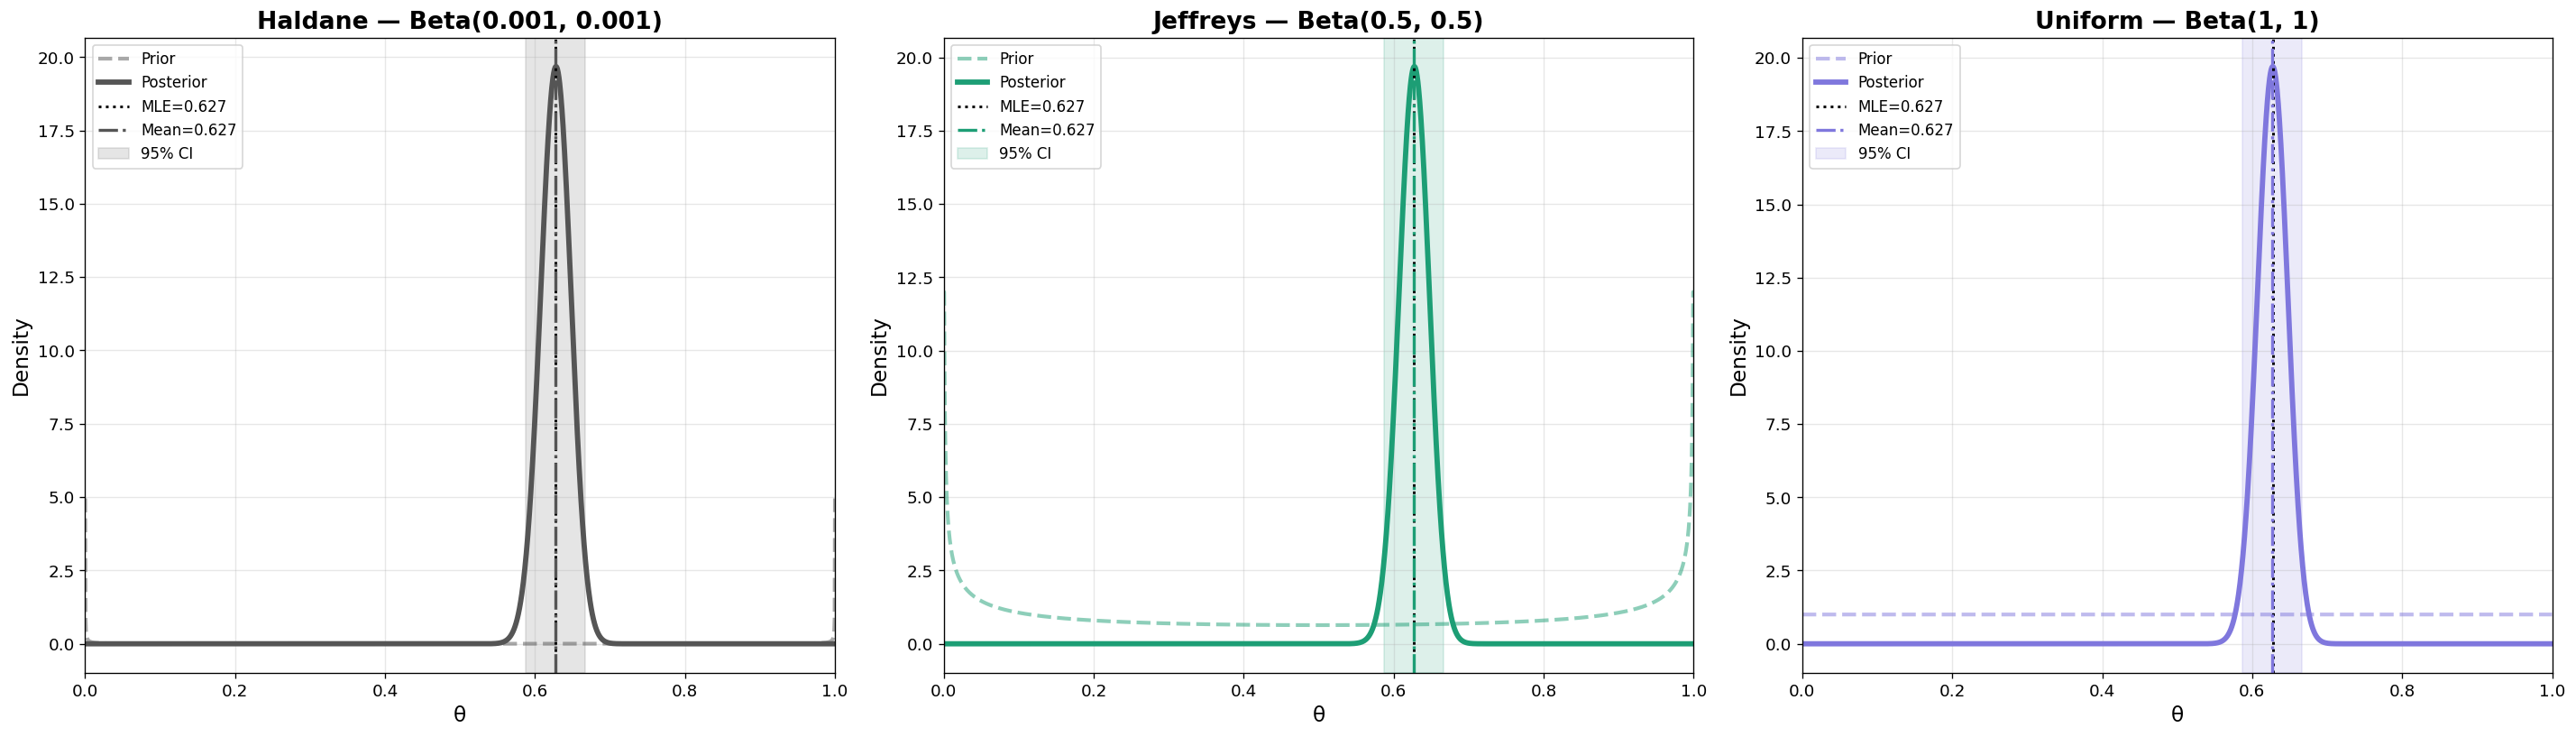

Saved: fig1a_priors.png.


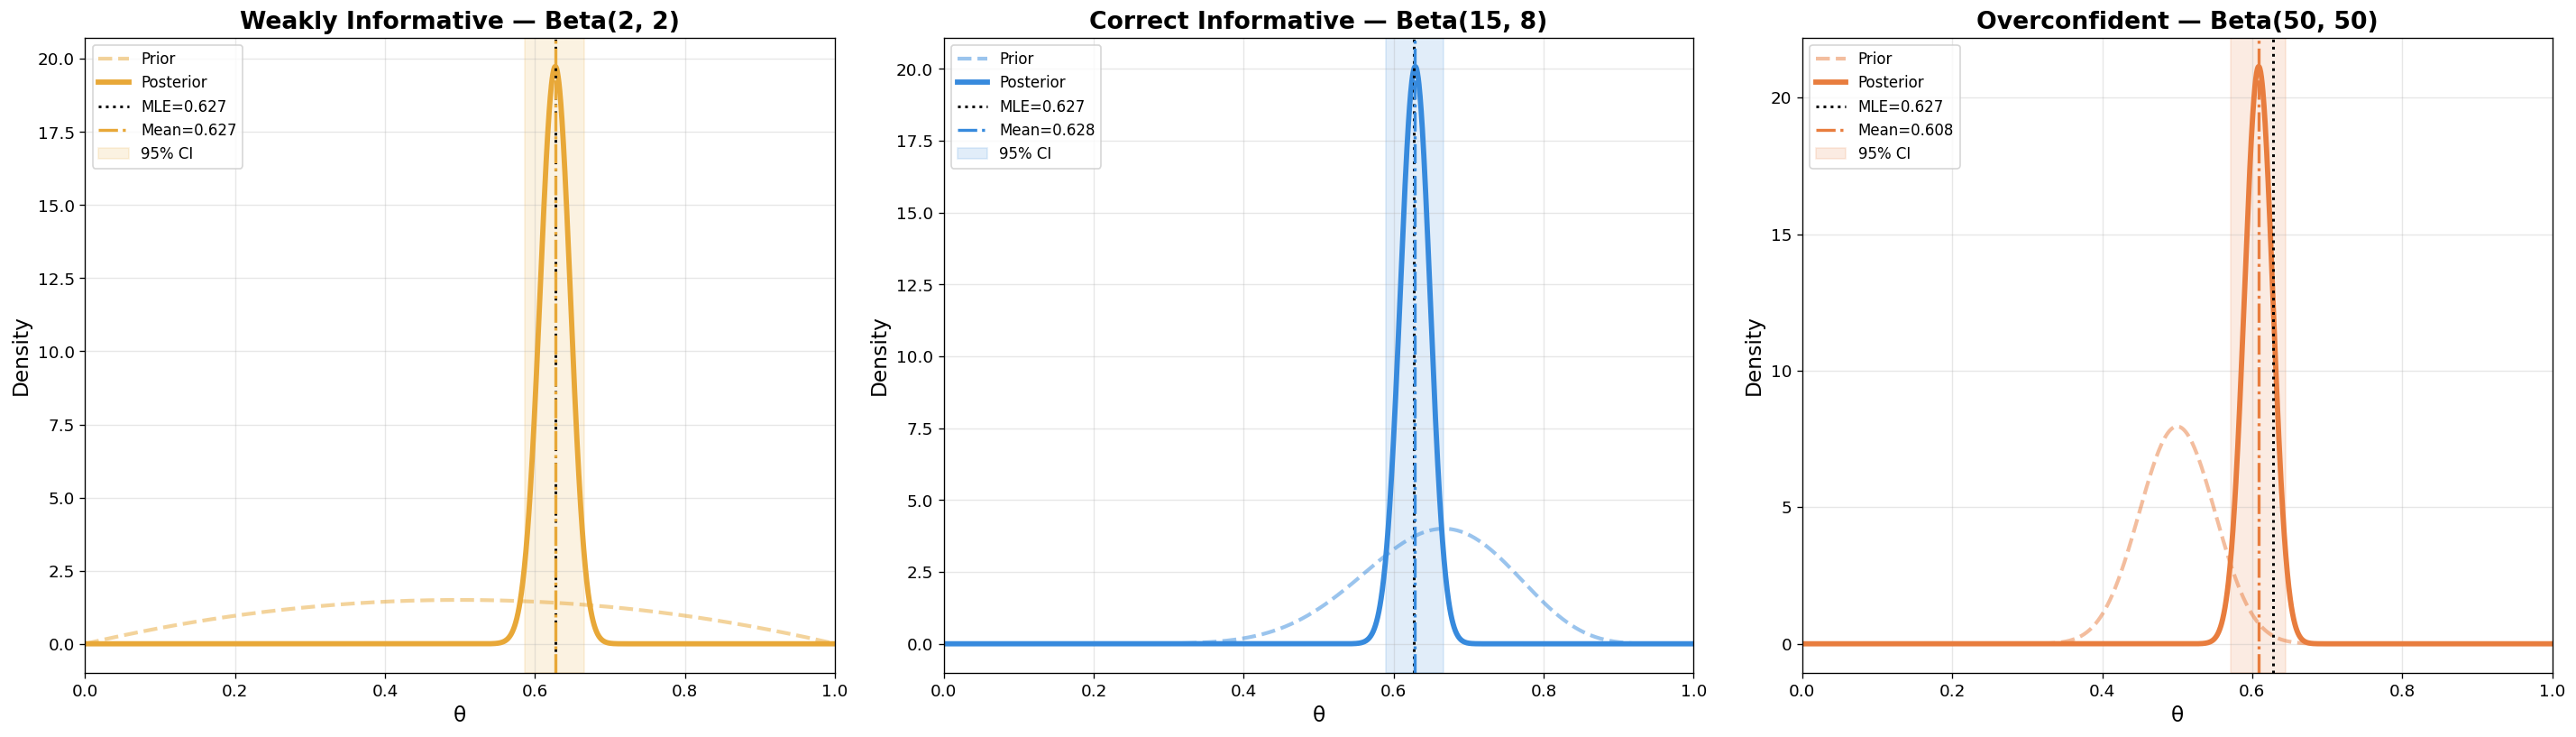

Saved: fig1b_priors.png.


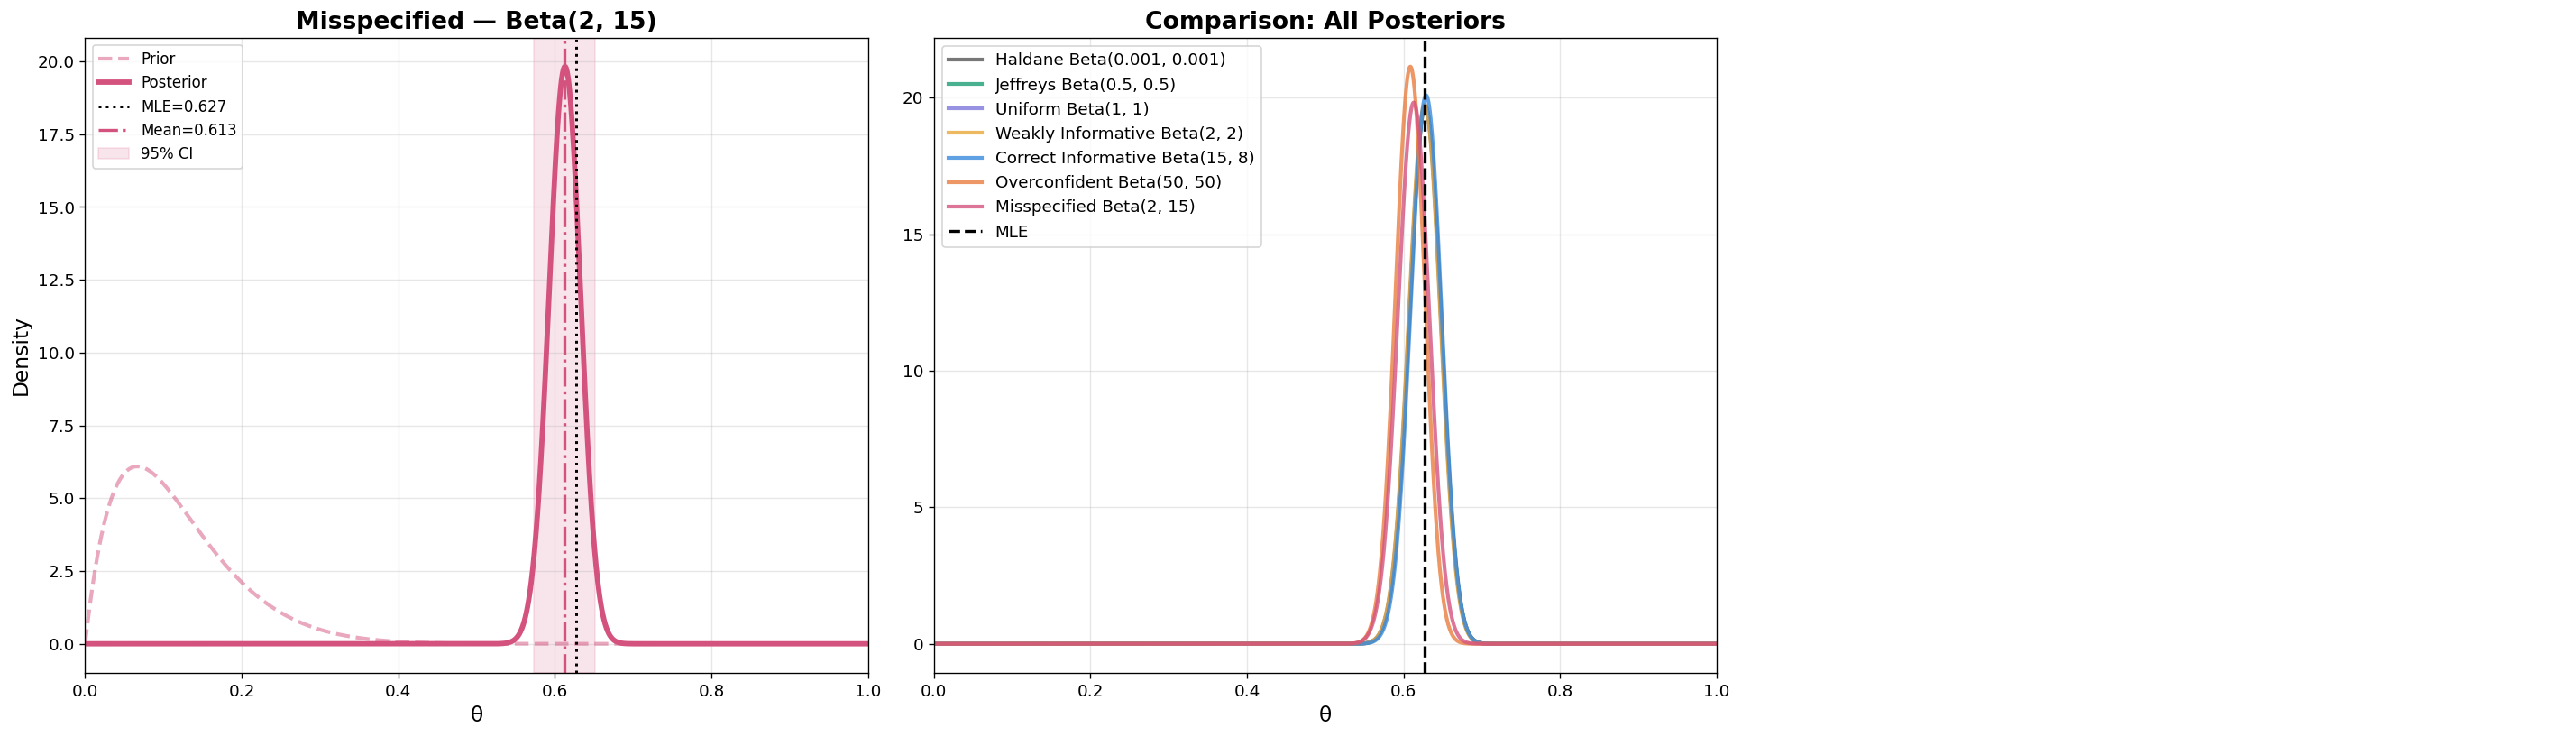

Saved: fig1c_priors.png.


In [ ]:
prior_items = list(priors.items())

chunks = [prior_items[0:3], prior_items[3:6], prior_items[6:7]]
filenames = ["fig1a_priors.png", "fig1b_priors.png", "fig1c_priors.png"]

for chunk_idx, chunk in enumerate(chunks):
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    for i, (name, p) in enumerate(chunk):
        ax = axes[i]

        prior_plot = np.clip(p["prior_pdf"], 0, 12)
        ax.plot(theta, prior_plot, '--', color=p["color"], alpha=0.5, linewidth=2.5, label="Prior")
        ax.plot(theta, p["post_pdf"], '-', color=p["color"], linewidth=3.5, label="Posterior")

        ax.axvline(MLE, color='black', linewidth=1.8, linestyle=':', label=f"MLE={MLE:.3f}")
        ax.axvline(p["post_mean"], color=p["color"], linewidth=2, linestyle='-.', label=f"Mean={p['post_mean']:.3f}")

        # 95% Credible Interval Shading
        lo = stats.beta.ppf(0.025, p["a_post"], p["b_post"])
        hi = stats.beta.ppf(0.975, p["a_post"], p["b_post"])
        ax.axvspan(lo, hi, alpha=0.15, color=p["color"], label="95% CI")

        ax.set_title(name.replace('\n', ' — '), fontsize=16, fontweight='bold')
        ax.set_xlabel("θ", fontsize=14)
        ax.set_ylabel("Density", fontsize=14)
        ax.legend(loc='upper left', fontsize=10)
        ax.set_xlim(0, 1)

    if chunk_idx == 2:
        ax_comp = axes[1]
        for name, p in priors.items():
            ax_comp.plot(theta, p["post_pdf"], color=p["color"], linewidth=2.5, alpha=0.8, label=name.replace('\n', ' '))

        ax_comp.axvline(MLE, color='black', linewidth=2, linestyle='--', label="MLE")
        ax_comp.set_title("Comparison: All Posteriors", fontsize=16, fontweight='bold')
        ax_comp.legend(fontsize=11, loc='upper left')
        ax_comp.set_xlim(0, 1)
        ax_comp.set_xlabel("θ", fontsize=14)

        axes[2].set_xticks([])
        axes[2].set_yticks([])
        axes[2].set_frame_on(False)
        axes[2].set_title("")

    plt.tight_layout()
    plt.savefig(filenames[chunk_idx], bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved: {filenames[chunk_idx]}.")

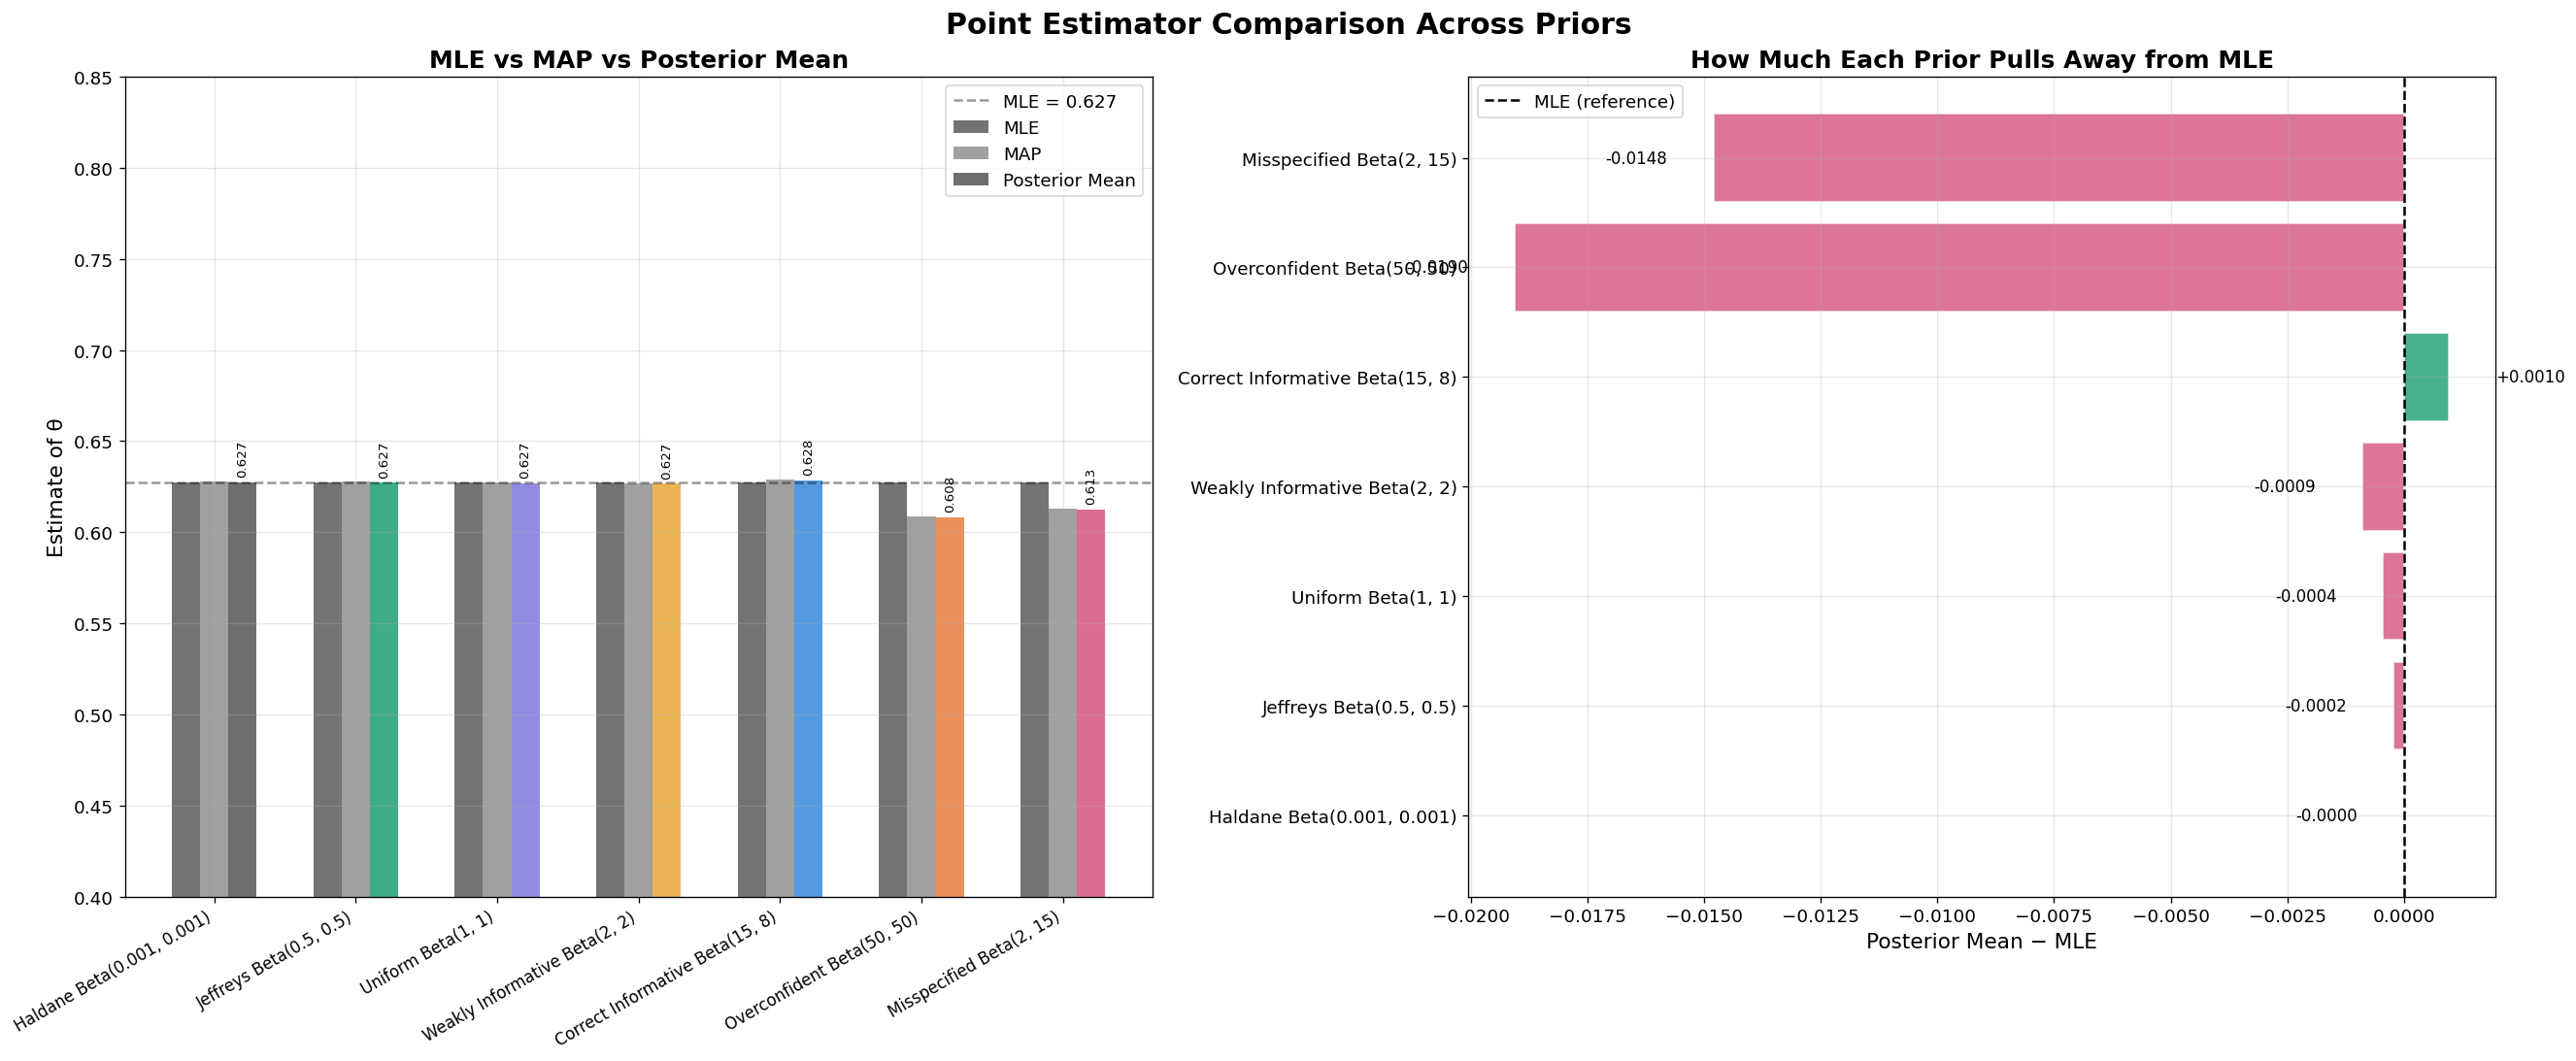

Saved: fig2_point_estimators.png



In [ ]:
# MLE vs MAP vs Posterior Mean vs Posterior Median

names_short = [name.replace('\n', ' ') for name in priors]
colors_list = [p["color"] for p in priors.values()]
x_idx = np.arange(len(priors))
width = 0.2

post_means   = [p["post_mean"]   for p in priors.values()]
post_medians = [p["post_median"] for p in priors.values()]
MAPs         = [p["MAP"] if p["MAP"] else p["post_mean"] for p in priors.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9), constrained_layout=True)
fig.suptitle("Point Estimator Comparison Across Priors", fontsize=18, fontweight='bold')

# ── Left: grouped bar chart ────────────────────────────────────────
bars_mle  = ax1.bar(x_idx - width,   [MLE]*len(priors),   width, label='MLE',
                    color='black', alpha=0.55)
bars_map  = ax1.bar(x_idx,           MAPs,                 width, label='MAP',
                    color='gray',  alpha=0.75)
bars_mean = ax1.bar(x_idx + width,   post_means,           width, label='Posterior Mean',
                    color=colors_list, alpha=0.85)

ax1.axhline(MLE, color='black', linestyle='--', linewidth=1.5,
            alpha=0.4, label=f"MLE = {MLE:.3f}")
ax1.set_xticks(x_idx)
ax1.set_xticklabels(names_short, rotation=30, ha='right', fontsize=10)
ax1.set_ylabel("Estimate of θ")
ax1.set_title("MLE vs MAP vs Posterior Mean", fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_ylim(0.4, 0.85)

for bar, val in zip(bars_mean, post_means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f"{val:.3f}", ha='center', va='bottom', fontsize=8, rotation=90)

# ── Right: deviation from MLE ─────────────────────────────────────
deviations = [pm - MLE for pm in post_means]
bar_colors = ['#D4537E' if d < 0 else '#1D9E75' for d in deviations]
bars = ax2.barh(names_short, deviations, color=bar_colors, alpha=0.8, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1.5, linestyle='--', label='MLE (reference)')
ax2.set_xlabel("Posterior Mean − MLE")
ax2.set_title("How Much Each Prior Pulls Away from MLE", fontweight='bold')
ax2.legend(fontsize=11)

for bar, dev in zip(bars, deviations):
    ax2.text(dev + (0.001 if dev >= 0 else -0.001),
             bar.get_y() + bar.get_height()/2,
             f"{dev:+.4f}", va='center', ha='left' if dev >= 0 else 'right', fontsize=10)

plt.savefig("fig2_point_estimators.png", bbox_inches='tight', dpi=130)
plt.show()
print("Saved: fig2_point_estimators.png")
print()

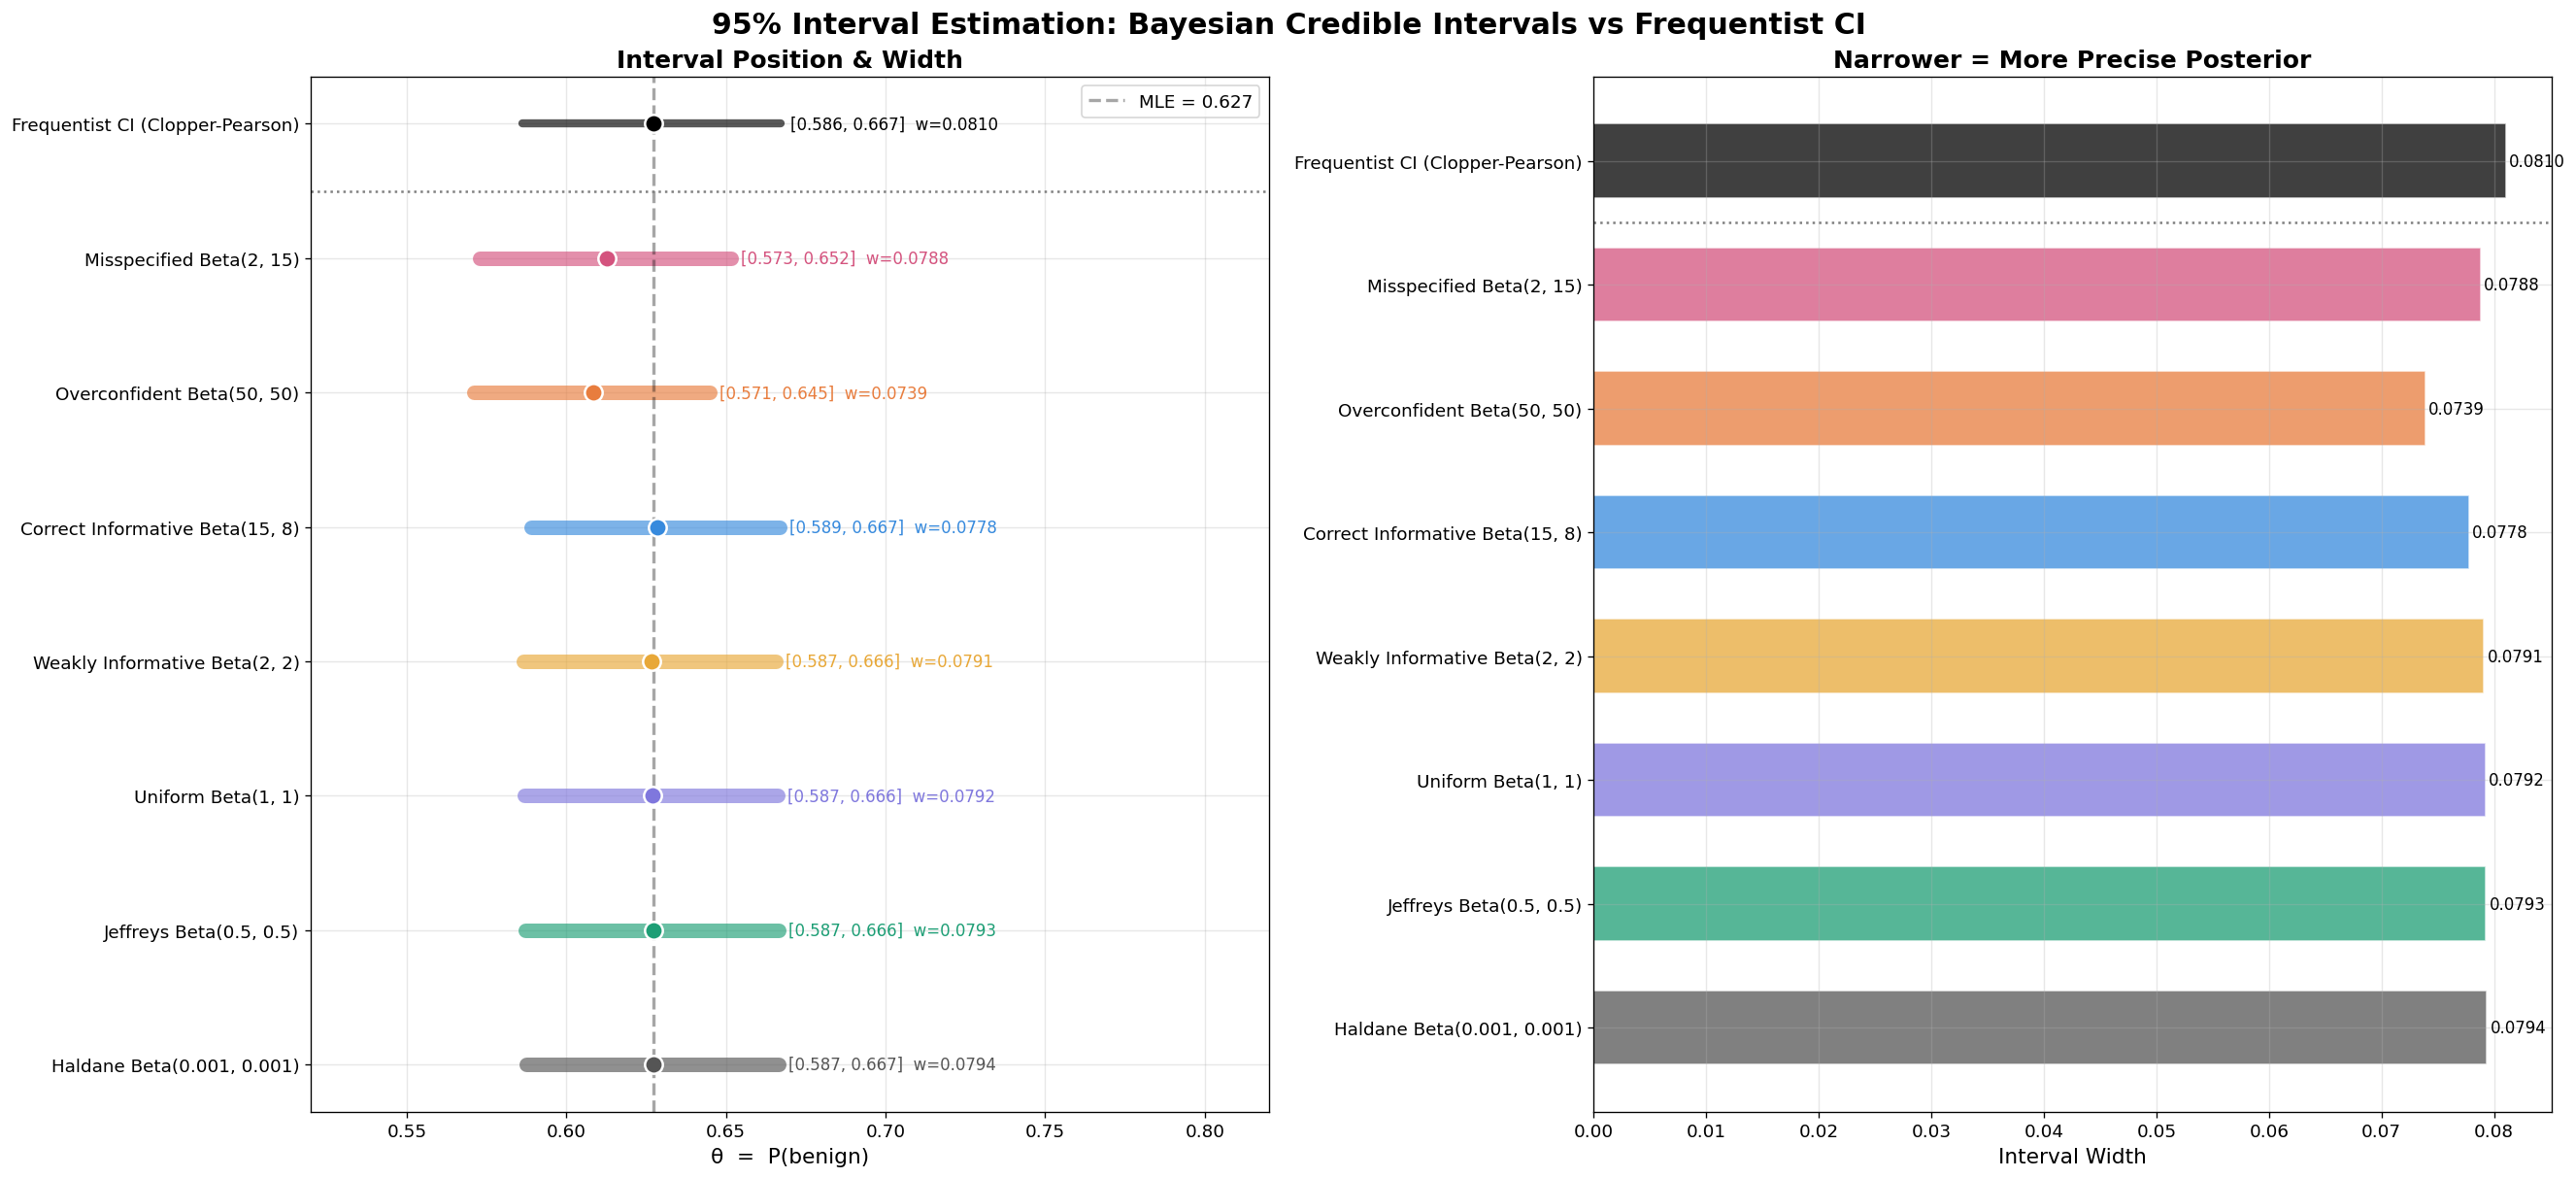

Saved: fig3_interval_estimation.png


In [ ]:
# 95% Credible Intervals vs Frequentist CI, + width comparison

# Frequentist Clopper-Pearson (for Binomial Distribution) exact CI
freq_lo = stats.beta.ppf(0.025, k,   n - k + 1)
freq_hi = stats.beta.ppf(0.975, k+1, n - k)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10), constrained_layout=True)
fig.suptitle("95% Interval Estimation: Bayesian Credible Intervals vs Frequentist CI",
             fontsize=18, fontweight='bold')

y_labels, y_colors, y_means, y_los, y_his = [], [], [], [], []

for name, p in priors.items():
    lo = stats.beta.ppf(0.025, p["a_post"], p["b_post"])
    hi = stats.beta.ppf(0.975, p["a_post"], p["b_post"])
    y_labels.append(name.replace('\n', ' '))
    y_colors.append(p["color"])
    y_means.append(p["post_mean"])
    y_los.append(lo)
    y_his.append(hi)

y_labels.append("Frequentist CI (Clopper-Pearson)")
y_colors.append('black')
y_means.append(MLE)
y_los.append(freq_lo)
y_his.append(freq_hi)

n_items = len(y_labels)
y_pos   = list(range(n_items))

# ── Left: horizontal intervals ─────────────────────────────────────
for i in range(n_items):
    lw = 9 if i < n_items - 1 else 5
    ax1.plot([y_los[i], y_his[i]], [i, i], '-',
             color=y_colors[i], linewidth=lw, alpha=0.65,
             solid_capstyle='round')
    ax1.plot(y_means[i], i, 'o', color=y_colors[i], markersize=11,
             zorder=5, markeredgecolor='white', markeredgewidth=1.5)
    ax1.text(y_his[i] + 0.003, i,
             f"[{y_los[i]:.3f}, {y_his[i]:.3f}]  w={y_his[i]-y_los[i]:.4f}",
             va='center', fontsize=10, color=y_colors[i])

ax1.axvline(MLE, color='black', linestyle='--', linewidth=2, alpha=0.35,
            label=f"MLE = {MLE:.3f}")
ax1.set_yticks(y_pos)
ax1.set_yticklabels(y_labels, fontsize=11)
ax1.set_xlabel("θ  =  P(benign)", fontsize=13)
ax1.set_title("Interval Position & Width", fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xlim(0.52, 0.82)
ax1.axhline(n_items - 1.5, color='gray', linestyle=':', linewidth=1.5)

# ── Right: interval widths ─────────────────────────────────────────
widths = [y_his[i] - y_los[i] for i in range(n_items)]
bar_colors = y_colors.copy()
bars = ax2.barh(y_pos, widths, color=bar_colors, alpha=0.75,
                edgecolor='white', height=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(y_labels, fontsize=11)
ax2.set_xlabel("Interval Width", fontsize=13)
ax2.set_title("Narrower = More Precise Posterior", fontweight='bold')
for bar, w in zip(bars, widths):
    ax2.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
             f"{w:.4f}", va='center', fontsize=10)
ax2.axhline(n_items - 1.5, color='gray', linestyle=':', linewidth=1.5)

plt.savefig("fig3_interval_estimation.png", bbox_inches='tight', dpi=130)
plt.show()
print("Saved: fig3_interval_estimation.png")

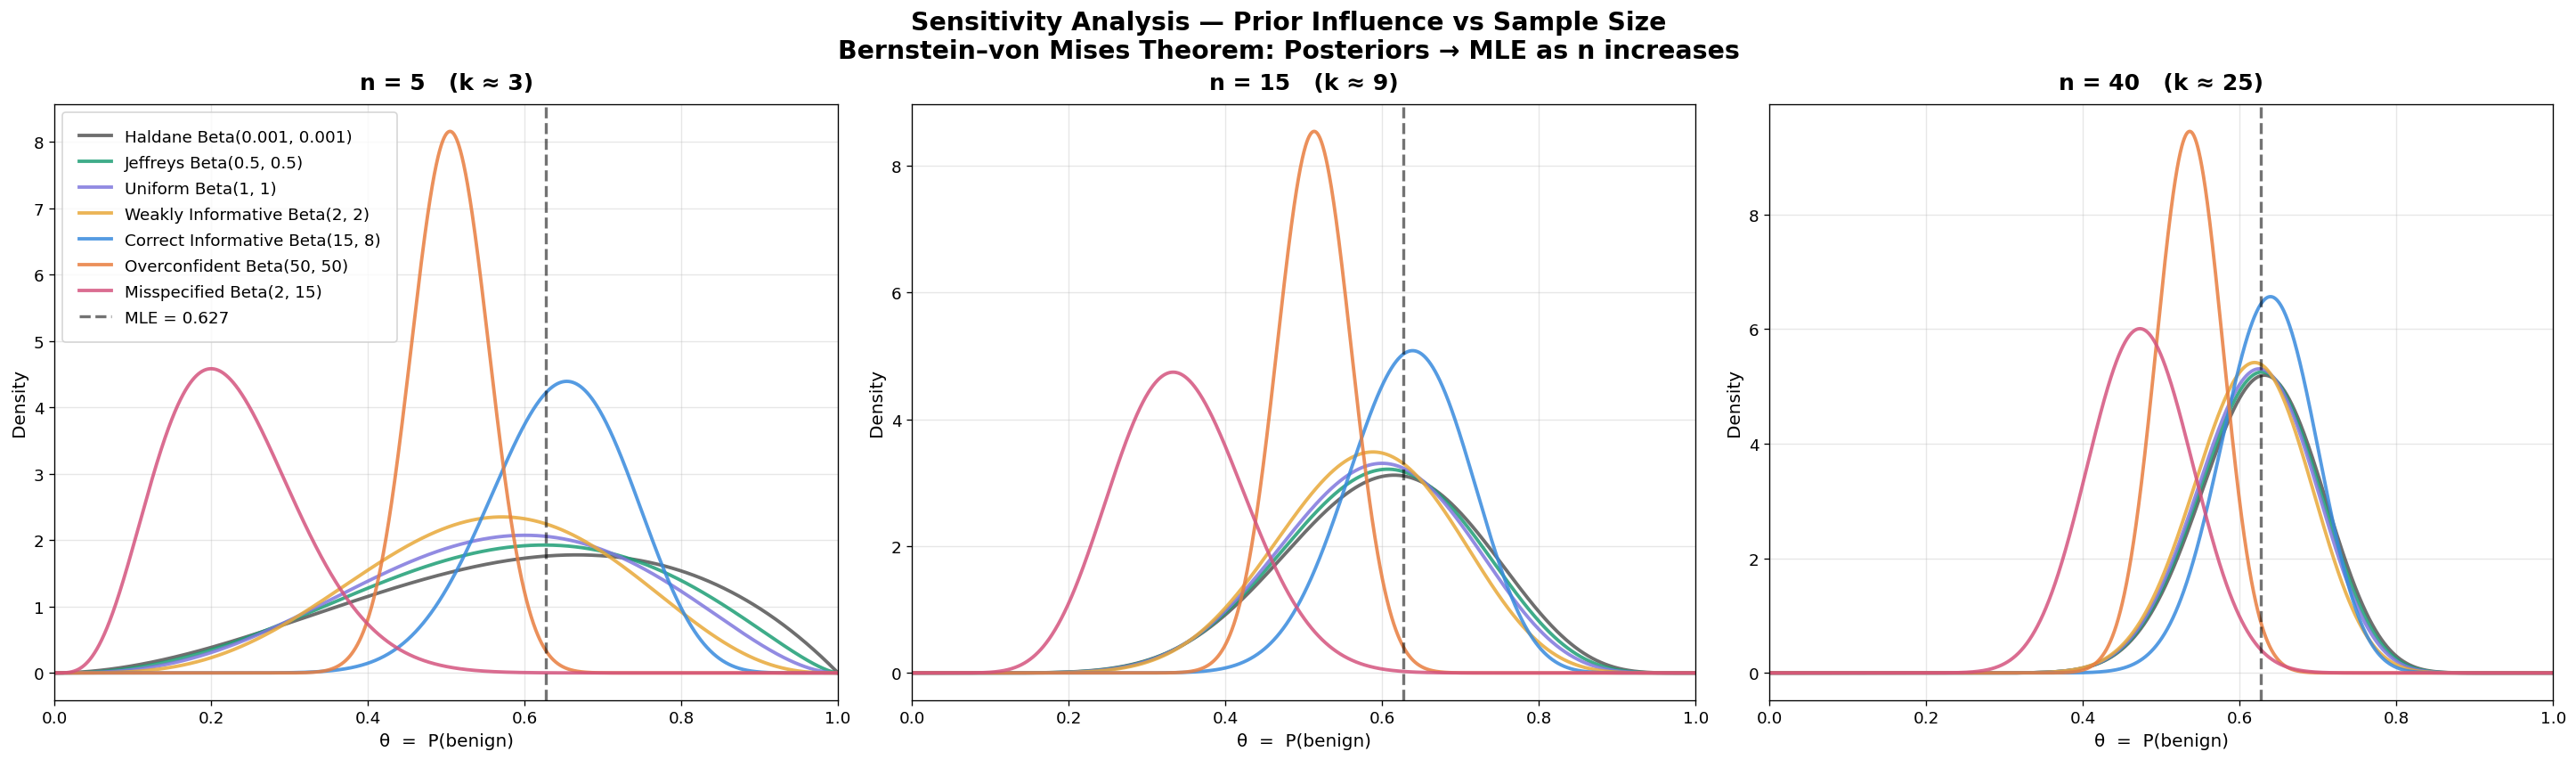

Saved: fig4a_sensitivity.png


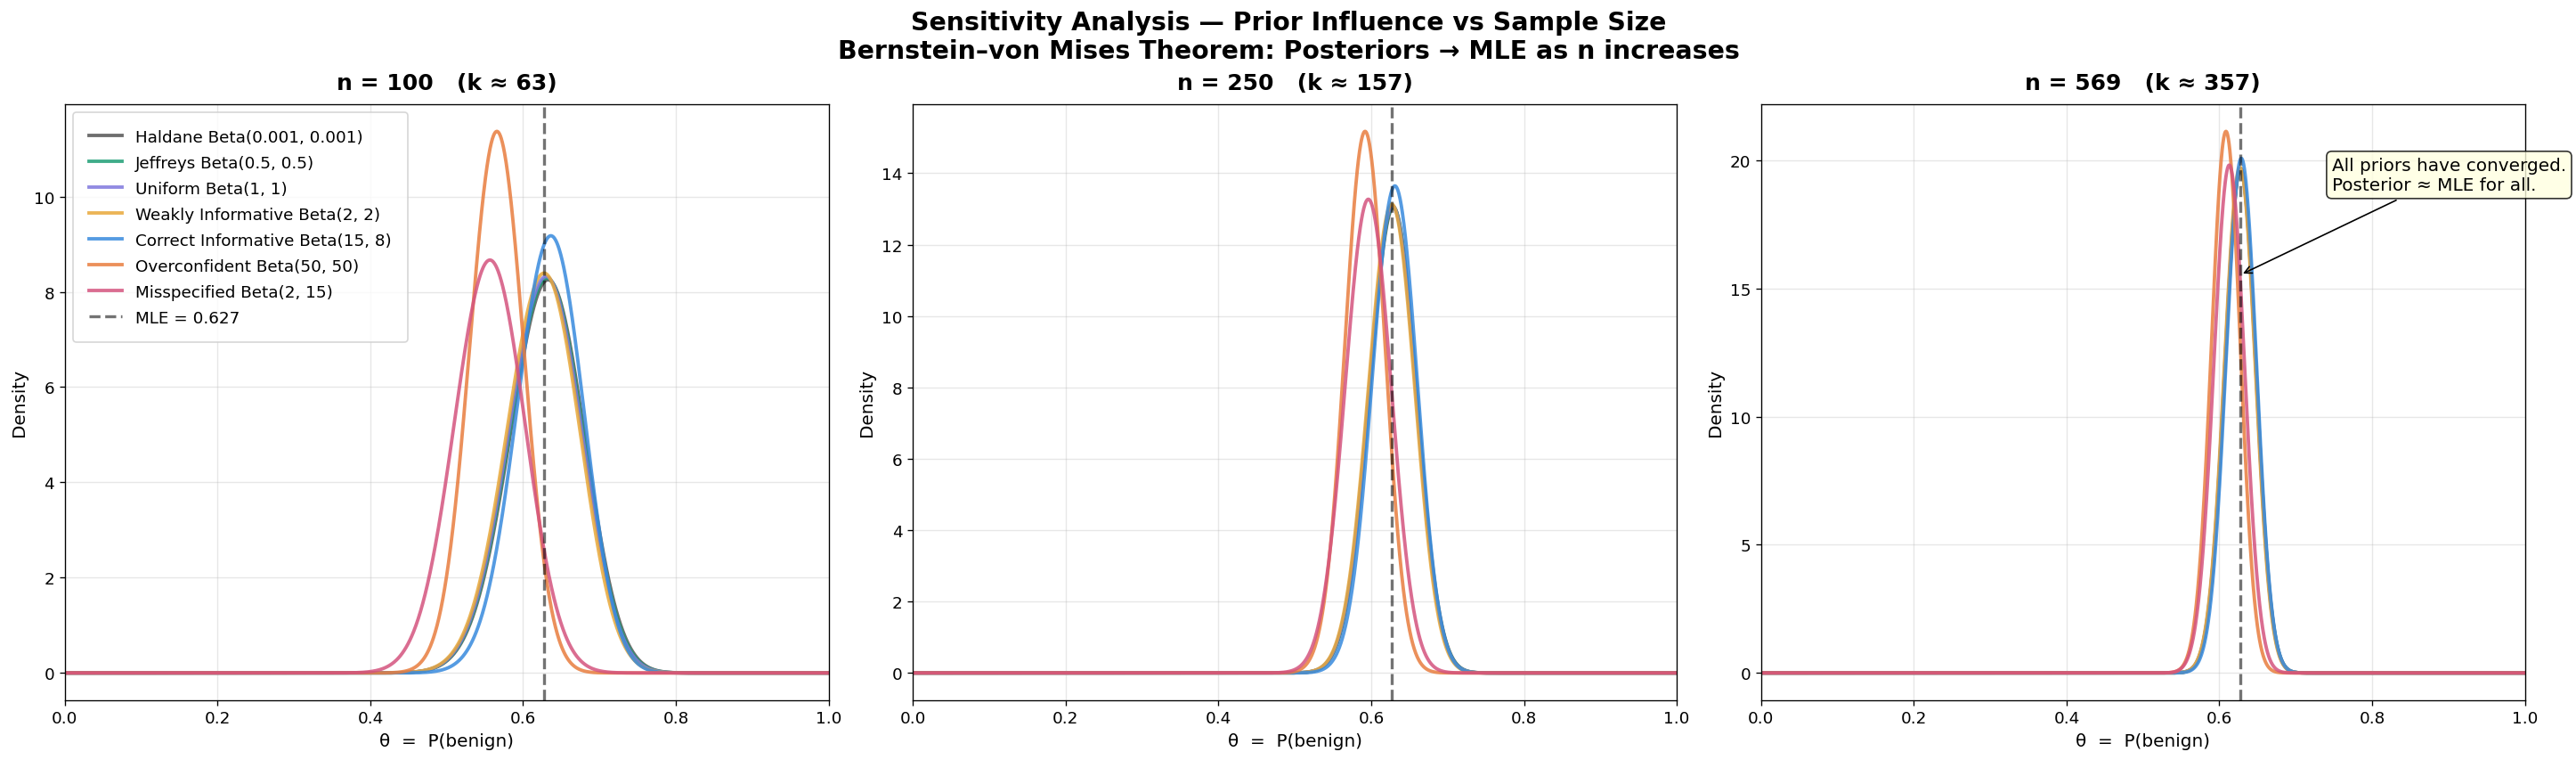

Saved: fig4b_sensitivity.png


In [ ]:
# How posteriors converge as n grows — Bernstein-von Mises Theorem

sample_sizes = [5, 15, 40, 100, 250, 569]
true_p = MLE   # use observed proportion as ground truth

chunks = [sample_sizes[:3], sample_sizes[3:]]
filenames = ["fig4a_sensitivity.png", "fig4b_sensitivity.png"]

for fig_idx, chunk in enumerate(chunks):

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), constrained_layout=True)

    fig.suptitle(
        "Sensitivity Analysis — Prior Influence vs Sample Size\n"
        "Bernstein–von Mises Theorem: Posteriors → MLE as n increases",
        fontsize=17, fontweight='bold'
    )

    for idx, n_val in enumerate(chunk):
        ax = axes[idx]
        k_val = int(round(true_p * n_val))

        for name, p in priors.items():
            a_p = p["a"] + k_val
            b_p = p["b"] + (n_val - k_val)
            pdf = stats.beta.pdf(theta, a_p, b_p)

            ax.plot(theta, pdf, color=p["color"], linewidth=2.3, alpha=0.85,
                    label=name.replace('\n', ' '))

        ax.axvline(true_p, color='black', linestyle='--', linewidth=2,
                   alpha=0.55, label=f"MLE = {true_p:.3f}")

        ax.set_title(f"n = {n_val}   (k ≈ {k_val})", fontweight='bold', pad=10)
        ax.set_xlabel("θ  =  P(benign)", fontsize=12)
        ax.set_ylabel("Density", fontsize=12)
        ax.set_xlim(0, 1)

        if idx == 0:
            ax.legend(
            fontsize=11,
            loc='upper left',
            frameon=True,
            borderpad=1,
            labelspacing=0.6,
            handlelength=2
        )


    if fig_idx == 1:
        ax_last = axes[-1]
        ax_last.annotate(
            "All priors have converged.\nPosterior ≈ MLE for all.",
            xy=(true_p, ax_last.get_ylim()[1]*0.7),
            xytext=(true_p + 0.12, ax_last.get_ylim()[1]*0.85),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=12, color='black',
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8)
        )

    plt.savefig(filenames[fig_idx], bbox_inches='tight', dpi=130)
    plt.show()
    print(f"Saved: {filenames[fig_idx]}")

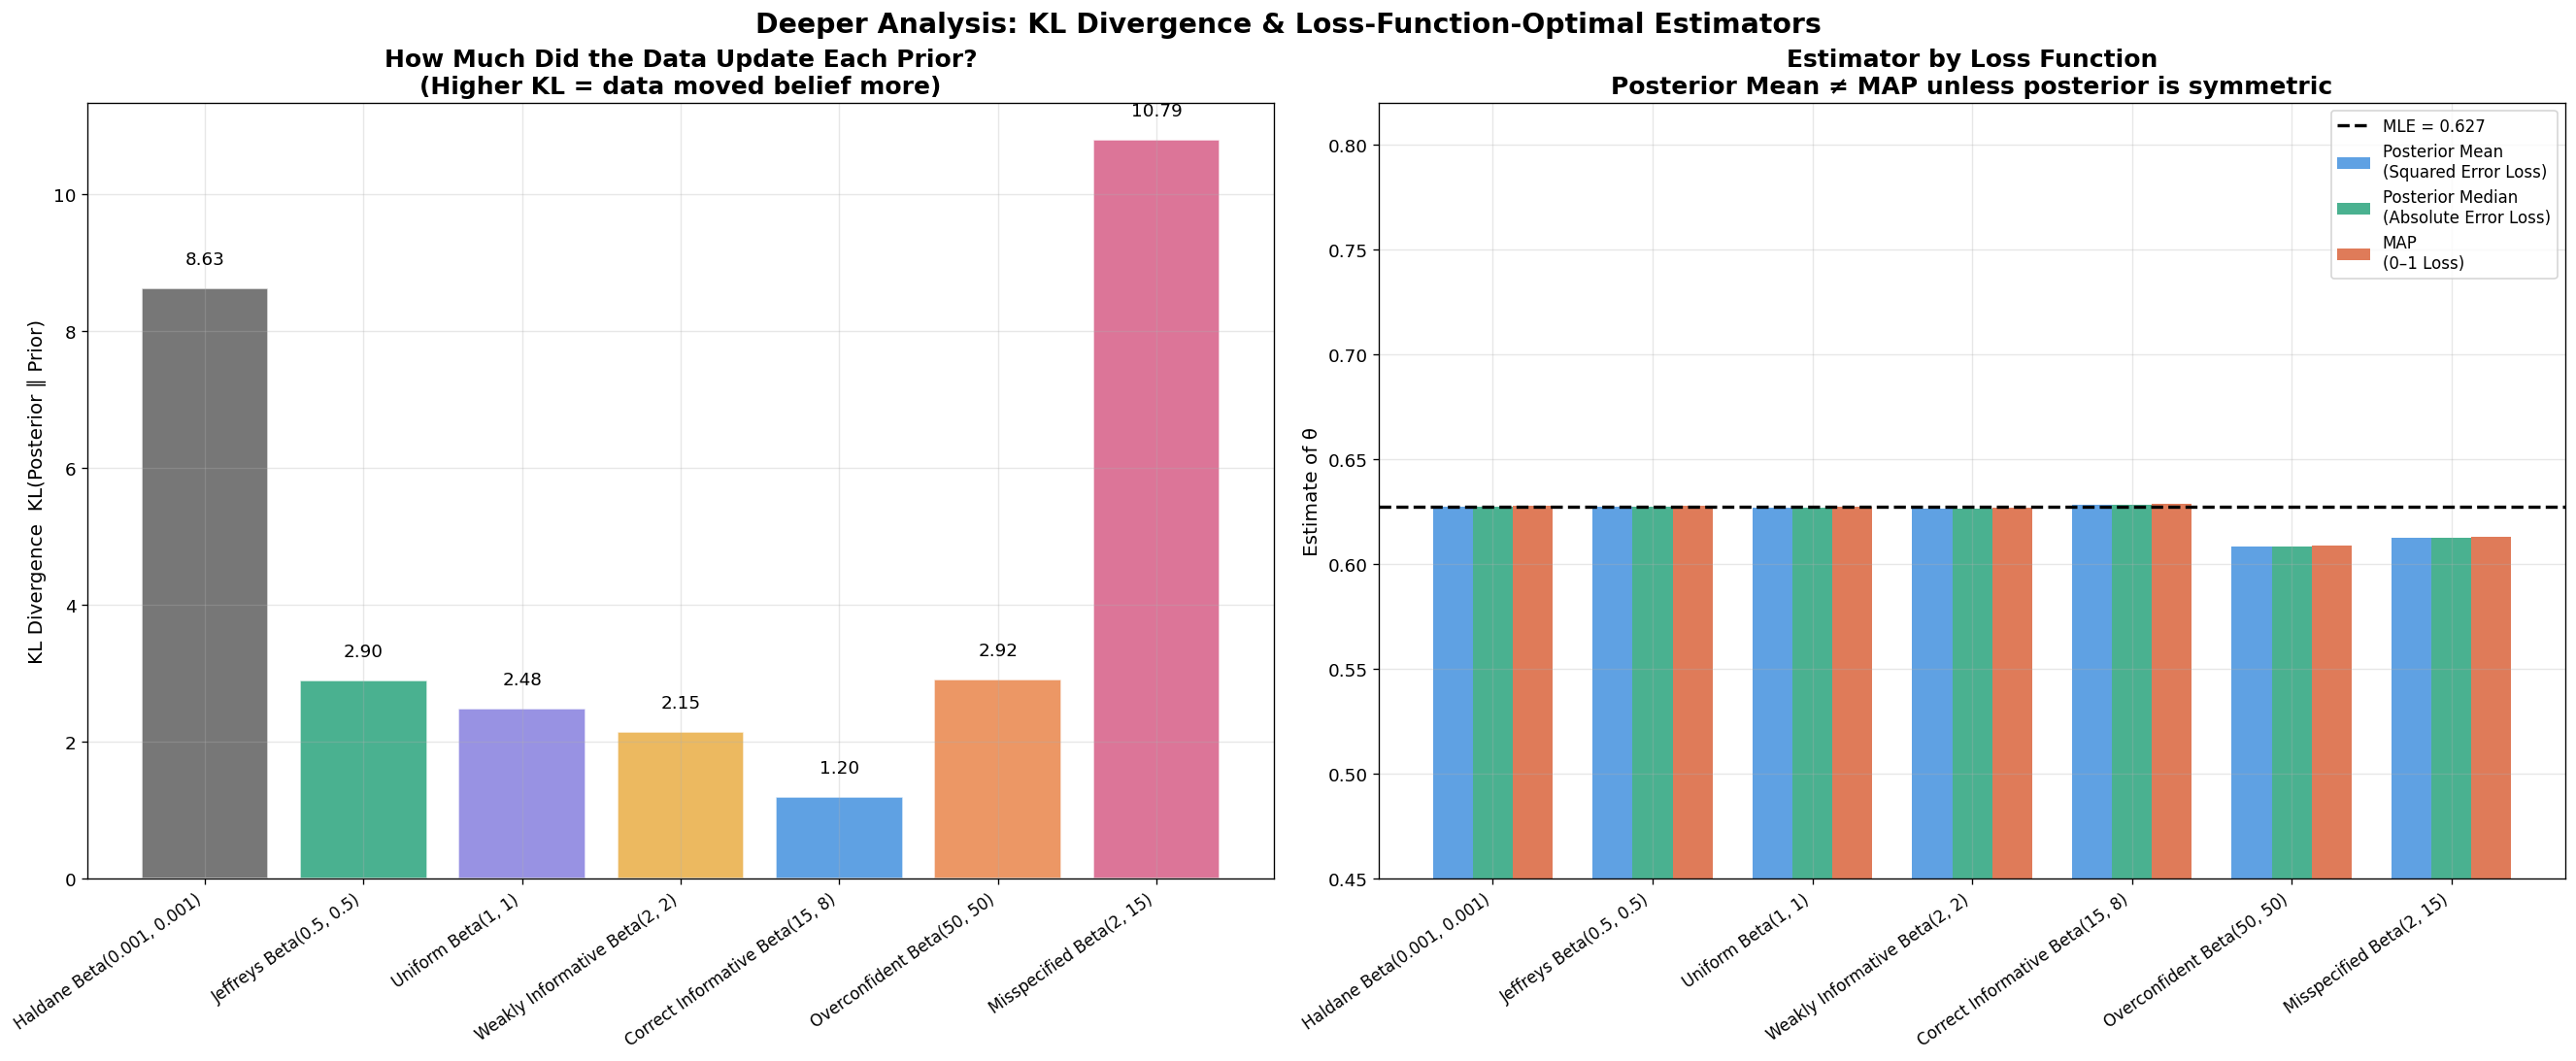

Saved: fig5_kl_and_loss.png


In [ ]:
# Two new analytical additions

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9), constrained_layout=True)
fig.suptitle("Deeper Analysis: KL Divergence & Loss-Function-Optimal Estimators",
             fontsize=17, fontweight='bold')

# ── Left: KL Divergence bar chart ─────────────────────────────────
names_s = [name.replace('\n', ' ') for name in priors]
kl_vals = [p["KL"] for p in priors.values()]
cols    = [p["color"] for p in priors.values()]

bars = ax1.bar(names_s, kl_vals, color=cols, alpha=0.8, edgecolor='white')
ax1.set_xticklabels(names_s, rotation=35, ha='right', fontsize=10)
ax1.set_ylabel("KL Divergence  KL(Posterior ∥ Prior)", fontsize=12)
ax1.set_title(
    "How Much Did the Data Update Each Prior?\n"
    "(Higher KL = data moved belief more)", fontweight='bold'
)
for bar, val in zip(bars, kl_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.2f}", ha='center', va='bottom', fontsize=11)

# ── Right: 3 estimators under 3 loss functions ────────────────────
estimator_data = {
    "Posterior Mean\n(Squared Error Loss)": [p["post_mean"]   for p in priors.values()],
    "Posterior Median\n(Absolute Error Loss)": [p["post_median"] for p in priors.values()],
    "MAP\n(0–1 Loss)": [p["MAP"] if p["MAP"] else p["post_mean"] for p in priors.values()],
}

x    = np.arange(len(priors))
w    = 0.25
offsets = [-w, 0, w]
est_colors = ['#378ADD', '#1D9E75', '#D85A30']

for (label, vals), offset, ec in zip(estimator_data.items(), offsets, est_colors):
    bars = ax2.bar(x + offset, vals, w, label=label, color=ec, alpha=0.8)

ax2.axhline(MLE, color='black', linewidth=2, linestyle='--',
            label=f"MLE = {MLE:.3f}")
ax2.set_xticks(x)
ax2.set_xticklabels(names_s, rotation=35, ha='right', fontsize=10)
ax2.set_ylabel("Estimate of θ", fontsize=12)
ax2.set_title(
    "Estimator by Loss Function\n"
    "Posterior Mean ≠ MAP unless posterior is symmetric",
    fontweight='bold'
)
ax2.legend(fontsize=10)
ax2.set_ylim(0.45, 0.82)

plt.savefig("fig5_kl_and_loss.png", bbox_inches='tight', dpi=130)
plt.show()
print("Saved: fig5_kl_and_loss.png")

In [ ]:
# Predicting P(next patient is benign | data, prior)

print("=" * 65)
print("  POSTERIOR PREDICTIVE:  P(X_new = 1 | data)")
print("  = E[θ | data] = Posterior Mean  (by Beta-Binomial identity)")
print("=" * 65)
print()
print(f"  MLE baseline (plug-in):  {MLE:.4f}")
print()
print(f"  {'Prior':<38} {'P(benign next patient)':>22}")
print("  " + "-"*62)
for name, p in priors.items():
    nm = name.replace('\n', ' ')
    print(f"  {nm:<38} {p['post_pred']:>22.4f}")

print()
print("  Interpretation:")
print("  Given this prior and the observed data, what is our")
print("  probability that the next unobserved patient is benign?")
print("  Under a non-informative prior, this essentially equals MLE.")
print("  Under misspecified prior, it is pulled toward the wrong belief")
print("  but less so than the prior alone — data corrects it.")

  POSTERIOR PREDICTIVE:  P(X_new = 1 | data)
  = E[θ | data] = Posterior Mean  (by Beta-Binomial identity)

  MLE baseline (plug-in):  0.6274

  Prior                                  P(benign next patient)
  --------------------------------------------------------------
  Haldane Beta(0.001, 0.001)                             0.6274
  Jeffreys Beta(0.5, 0.5)                                0.6272
  Uniform Beta(1, 1)                                     0.6270
  Weakly Informative Beta(2, 2)                          0.6265
  Correct Informative Beta(15, 8)                        0.6284
  Overconfident Beta(50, 50)                             0.6084
  Misspecified Beta(2, 15)                               0.6126

  Interpretation:
  Given this prior and the observed data, what is our
  probability that the next unobserved patient is benign?
  Under a non-informative prior, this essentially equals MLE.
  Under misspecified prior, it is pulled toward the wrong belief
  but less so than the

In [ ]:
print("=" * 95)
print("  COMPLETE SUMMARY TABLE")
print("=" * 95)
header = f"{'Prior':<38} {'Post.Mean':>10} {'Median':>8} {'MAP':>8} {'95% CI':>20} {'Width':>7} {'KL':>7}"
print(header)
print("-" * 95)

for name, p in priors.items():
    lo = stats.beta.ppf(0.025, p["a_post"], p["b_post"])
    hi = stats.beta.ppf(0.975, p["a_post"], p["b_post"])
    nm     = name.replace('\n', ' ')
    map_s  = f"{p['MAP']:.4f}" if p['MAP'] else "undef."
    ci_str = f"[{lo:.3f}, {hi:.3f}]"
    print(f"{nm:<38} {p['post_mean']:>10.4f} {p['post_median']:>8.4f} "
          f"{map_s:>8} {ci_str:>20} {hi-lo:>7.4f} {p['KL']:>7.2f}")

lo_f = stats.beta.ppf(0.025, k, n - k + 1)
hi_f = stats.beta.ppf(0.975, k+1, n - k)
print("-" * 95)
print(f"{'Frequentist CI (Clopper-Pearson)':<38} {MLE:>10.4f} {'':>8} {MLE:>8.4f} "
      f"{f'[{lo_f:.3f}, {hi_f:.3f}]':>20} {hi_f-lo_f:>7.4f} {'—':>7}")

print(f"\n  MLE = {MLE:.4f}  (reference — no prior)\n")

print("""
OBSERVATIONS:
─────────────────────────────────────────────────────────────────────

1. MLE vs Bayesian estimators
   • MAP = MLE only under the Uniform prior. Under all others, the prior
     pulls MAP away from MLE.
   • Posterior Mean under Uniform = (k+1)/(n+2) — exactly Laplace smoothing.
   • With n=569, all estimators are very close to MLE — data dominates.

2. Role of prior strength
   • Overconfident Beta(50,50) creates the largest deviation from MLE
     despite a symmetric prior — it simply resists data too strongly.
   • Misspecified Beta(2,15) is pulled far from MLE in the wrong direction
     but is still corrected substantially by 569 data points.

3. Interval estimation
   • Bayesian credible interval: P(θ ∈ [lo,hi] | data) = 0.95  ← direct
   • Frequentist CI: 95% of intervals constructed this way contain θ — θ
     is fixed, not random. Cannot assign P(θ ∈ CI) = 0.95.
   • Under Jeffreys/Uniform priors, credible interval ≈ Clopper-Pearson CI.
   • Informative priors narrow the interval; misspecified ones shift it.

4. KL Divergence
   • Misspecified and Overconfident priors show highest KL — data had to
     work hardest to update a strongly wrong belief.
   • Haldane prior shows low KL because it was already diffuse — any data
     provides a large update efficiently.

5. Bernstein–von Mises (sensitivity analysis)
   • At n=5, posteriors are dominated by prior and widely spread.
   • By n=100+, all posteriors converge near MLE regardless of prior.
   • Convergence is slower for Overconfident Beta(50,50).

6. Posterior Predictive
   • P(next patient benign | data) = Posterior Mean — a direct, useful
     output that bridges inference and prediction.
""")

  COMPLETE SUMMARY TABLE
Prior                                   Post.Mean   Median      MAP               95% CI   Width      KL
-----------------------------------------------------------------------------------------------
Haldane Beta(0.001, 0.001)                 0.6274   0.6276   0.6279       [0.587, 0.667]  0.0794    8.63
Jeffreys Beta(0.5, 0.5)                    0.6272   0.6273   0.6276       [0.587, 0.666]  0.0793    2.90
Uniform Beta(1, 1)                         0.6270   0.6271   0.6274       [0.587, 0.666]  0.0792    2.48
Weakly Informative Beta(2, 2)              0.6265   0.6267   0.6270       [0.587, 0.666]  0.0791    2.15
Correct Informative Beta(15, 8)            0.6284   0.6285   0.6288       [0.589, 0.667]  0.0778    1.20
Overconfident Beta(50, 50)                 0.6084   0.6085   0.6087       [0.571, 0.645]  0.0739    2.92
Misspecified Beta(2, 15)                   0.6126   0.6128   0.6130       [0.573, 0.652]  0.0788   10.79
---------------------------------------